# Análisis Estratégico para Campañas de Marketing en el Sector de Videojuegos
**Objetivo del Proyecto:** Analizar datos históricos de ventas, géneros, plataformas y calificaciones de expertos y usuarios para identificar los patrones que determinan el éxito comercial de un videojuego. Los hallazgos de este análisis tienen como propósito detectar productos con alto potencial de rentabilidad y optimizar el presupuesto de las campañas publicitarias del próximo año.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

df = pd.read_csv('games.csv')


In [4]:
df.columns = df.columns.str.lower()
df.year_of_release = df.year_of_release.fillna(0)
df.year_of_release = df.year_of_release.astype(int)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

- Cambie el tipo de datos de la columna de fecha a tipo entero, considero es más fiable para manejarla de esa manera que un flotante.

- Los valores ausentes los rellenare como ceros ya que es evidente que no se tiene info de ellos, los datos correspondientes al ratin quedaran en blanco ya que no considero que impaquen en el analisis

-Valores ausentes en columna de fecha:
Es probable que no se haya actualizado la informacion correctamente por lo que habria que realizar la investigacion correspondiente y complementar.

-Valores ausentes de critic score:
Es muy probable que la info no se actualice correctamente y tampocose le de seguimieto.

-Valores ausentes de  score:
Es muy probable que la info no se actualice correctamente y tampocose le de seguimieto.

- Datos con TBD
Estos datos los considerare como cero ya que es lo mismo que no tenerlo al momento de realizar el analisis

In [5]:
# Ventas totales por regiones
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
     
print(df)

                                name platform  year_of_release         genre  \
0                         Wii Sports      Wii             2006        Sports   
1                  Super Mario Bros.      NES             1985      Platform   
2                     Mario Kart Wii      Wii             2008        Racing   
3                  Wii Sports Resort      Wii             2009        Sports   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

* La competencia entre psp y xb es muy cerrada, observamos que al actualizarse a ps2 y x360, liderean como las plataformas con mas ventas y juegos estrenados

<Axes: xlabel='year_of_release'>

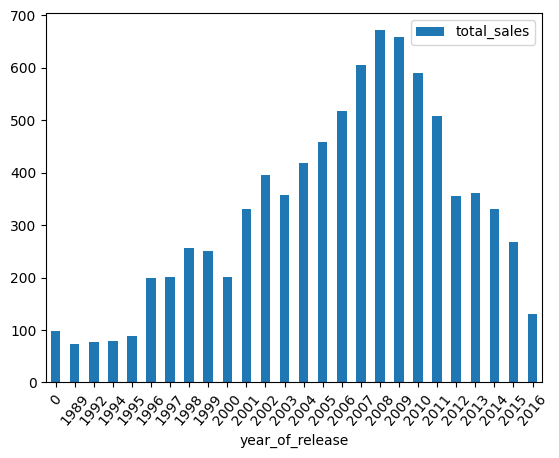

In [6]:
# Agrupar por 'year_of_release', sumando las ventas
df_sales = df.groupby(['year_of_release']).agg({'total_sales': 'sum'})

# Filtrar los grupos con ventas totales mayores a 60
df_sales2 = df_sales[df_sales['total_sales'] > 60]

# Restablecer el índice para convertir 'platform' y 'year_of_release' en columnas
df_sales2_reset = df_sales2.reset_index()

# Graficar los datos con 'year_of_release' como una columna
graf = df_sales2_reset.plot(kind='bar', x='year_of_release', y='total_sales', rot=50)
graf

*** Aqui observamos como ha sido la distribucion en ventas por año, el pico más alto se observa en los años 2008 y 2009, despues de ello comienca a disminuir.

<Axes: xlabel='platform'>

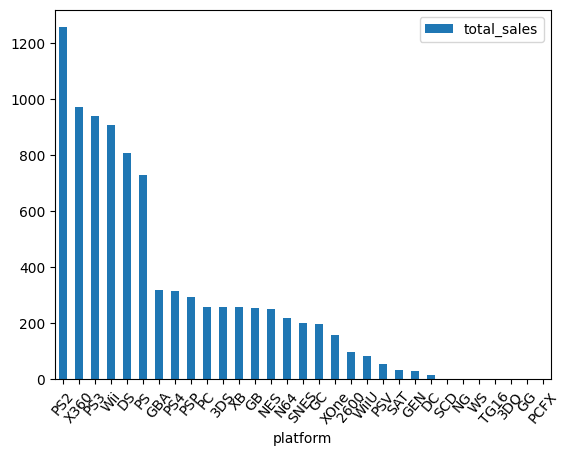

In [7]:
# Busca las plataformas que solían ser populares pero que ahora no tienen ventas. 
df_plat = df.groupby(['platform'])['total_sales'].sum()
df_plat = df_plat.reset_index(drop=False).rename(columns={'total':'platform'}) 
df_platf = df_plat.sort_values('total_sales',ascending=False)
df_platf.plot(kind='bar', x='platform',y='total_sales',rot=50)

*** Aqui observamos como las plataformas ps, psp,xb,n64, han dejado de tener lanzamiento y ventas debido a las nuevas plataformas que se han incorporado en el mercado, lo que lleva a que se actualicen y creen nuevas plataformas.

In [8]:
def company_sort (rating):
    if rating in ['3DS','DS','GB','GBA','GC','N64','NES','SNES','Wii','WiiU']:
        return "Nintendo"
    elif rating in ['PC']:
        return "PC"
    elif rating in ['PS','PS2','PS3','PS4','PSP','PSV']:
        return "PlayStation"
    elif rating in ['X360','XB','XOne']:
        return "XBox"
    else:
        return "Other"
        
df['company'] = df['platform'].apply(company_sort)


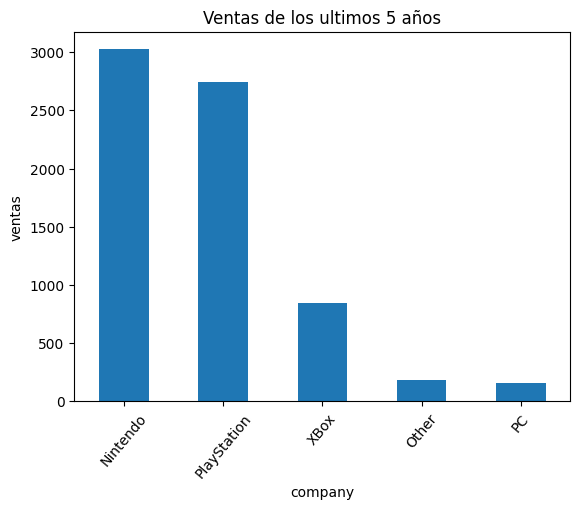

In [9]:
df_model = df[df['year_of_release']<2011].groupby('company')['total_sales'].sum().sort_values(ascending=False)
df_model_gf = df_model.plot(kind='bar',rot=50,ylabel='ventas',title='Ventas de los ultimos 5 años') 

Aqui podemos observar que nintendo va lidereado las ventas con la variedad de plataformas con las que cuenta, le sigue de cerca play station, quien tambien cuenta con diversas consolas y xbox, se va resagando considerando que tiene menos diversidad en las consolas que comercializa. Lo que nos podría decir que la competencia aumentara para el siguiente año.

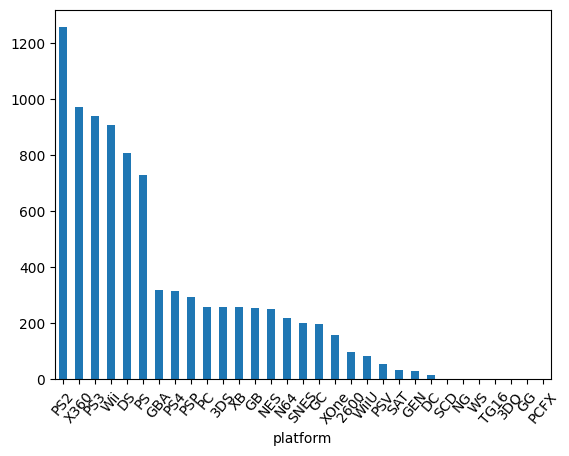

In [10]:
ventas = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
ventas_gf = ventas.plot(kind='bar',rot=50)
                       

--- En esta grafica podemos observar que las plataformas que liderean las ventas de manera mas especifica, con ps2 como plataforma preferida entre la comunidad de gamers, y xbox 360 va muy cerca. 

---La tecnologia va cambiando por lo que observamos que las plataformas que tienen una nueva consola, paulatinamente van perdiendo el interes de los gamers, como lo vemos en PS, XB,N64.

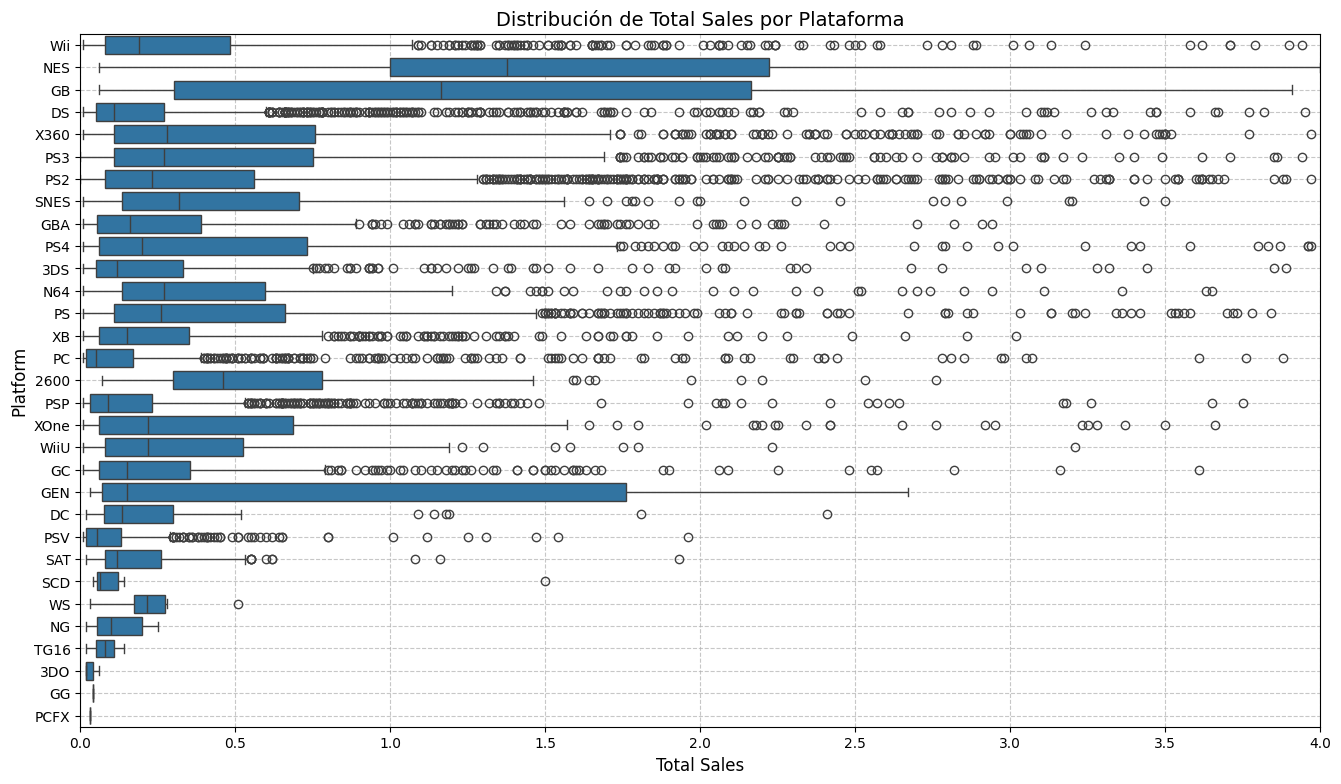

In [14]:
plt.figure(figsize=(16, 9))
sns.boxplot(x='total_sales', y='platform', data=df, orient='h')
plt.title('Distribución de Total Sales por Plataforma', fontsize=14)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Platform', fontsize=12)
plt.xlim(0, 4)
plt.grid(True, linestyle="--", alpha=0.7)  # Agregar cuadrícula suave
plt.show()

Podemos decir que se mantiene la venta en general de los juego.

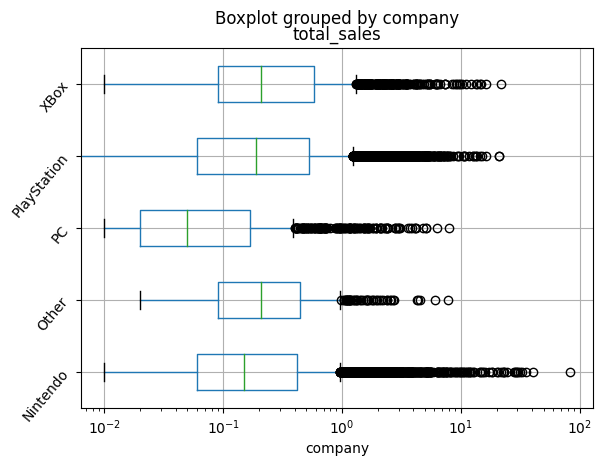

In [ ]:
df.boxplot(vert=False,
    column='total_sales',
    by='company',rot=50
)
plt.xscale('log') 
plt.show()

Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

*** Aqui lo inte plasmar de alguna manera mas general, pero tampoco es claro.

Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.


Correlación entre las reseñas de críticos y las ventas: 0.15


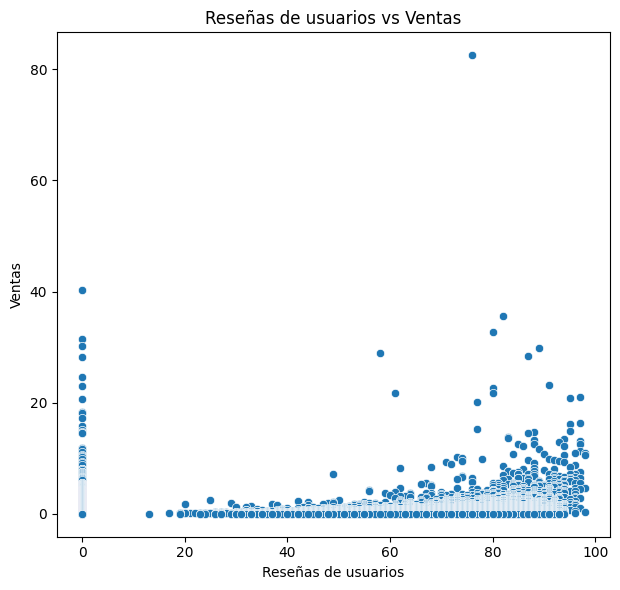

In [ ]:
# Calcular la correlación entre reseñas de usuarios y ventas
correlation_critic_sales = df['critic_score'].corr(df['total_sales'])

# Mostrar las correlaciones
print(f"Correlación entre las reseñas de críticos y las ventas: {correlation_critic_sales:.2f}")

# Crear gráfico de dispersión para visualizar la relación
plt.figure(figsize=(12, 6))

# Gráfico de dispersión entre reseñas de usuarios y ventas
plt.subplot(1, 2, 1)
sns.scatterplot(x='critic_score', y='total_sales', data=df)
plt.title('Reseñas de usuarios vs Ventas')
plt.xlabel('Reseñas de usuarios')
plt.ylabel('Ventas')

# Mostrar gráficos
plt.tight_layout()
plt.show()

-- Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.

In [ ]:
#filtro por compañía y selecciono las 5 plataformas con más ventas en norteamerica
games_na = df.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
games_na

platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

In [ ]:
np.var(df['na_sales'])

0.6619110892441236

Las plataformas más jugadas en la region de norteamerica son X360 y PS2,tiene una varianza pequeña en comparacion al mercado de europa, pero la diferencia es mayor con el mercado japones.

In [ ]:
#filtro por compañía y selecciono las 5 plataformas con más ventas en europa
games_ue = df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
games_ue

platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

In [ ]:
np.var(df['eu_sales'])

0.2533345028878412

Las plataformas más jugadas en la region de europa son PS2 y PS3,tiene una varianza pequeña en comparacion al mercado de norteamerica, pero la diferencia es mayor con el mercado japones.

In [ ]:
#filtro por compañía y selecciono las 5 juegos con más ventas en Japon
gamesjp = df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
gamesjp

platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64

In [ ]:
np.var(df['jp_sales'])

0.09538473164860495

Las plataformas más jugadas en la region de japonesa son DS y PS,tiene una diferencia considerable en la varianza comparada con los mercados de Europa y Norteamerica.

-- Los cinco géneros principales. Explica la diferencia.

In [ ]:
gene_na = df.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
gene_na

genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

In [ ]:
gene_eu = df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
gene_eu

genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

In [ ]:
gene_jp = df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
gene_jp

genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64

Los gamers de Europa y Norteamerica, tienen un gusto marcado por los juegos de acción seguido por los de deportes y los shooter, en el mercado japones es diferemte ya que prefieren por mucho los juejos de Role-Playing, seguido de los juegos de acción y deportes.

-- Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [ ]:
df.groupby('rating')['na_sales'].sum().sort_values(ascending=False)

rating
E       1292.99
T        759.75
M        748.48
E10+     353.32
K-A        2.56
EC         1.53
AO         1.26
RP         0.00
Name: na_sales, dtype: float64

In [ ]:
df.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)

rating
E       710.25
M       483.97
T       427.03
E10+    188.52
AO        0.61
K-A       0.27
EC        0.11
RP        0.08
Name: eu_sales, dtype: float64

In [ ]:
df.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

rating
E       198.11
T       151.40
M        64.24
E10+     40.20
K-A       1.46
AO        0.00
EC        0.00
RP        0.00
Name: jp_sales, dtype: float64

Si, considero que la clasificacion de los juegos da un valor agregado al los gamers, podemos observar que los juegos con clasificacion E, es la que mas abarca en la preferencia del publico, en norteamerica y japon se encuentra los juegos para jovenes seguido de la población madura, en Europa aunque el segundo sitio pertenece a la comunidad madura, no hay mucha diferencia con los gamers jovenes.


Hipótesis 1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
Hipótesis nula (H₀): Las calificaciones promedio para Xbox One y PC son iguales.
H0: Xbox one y PC son iguales.
H1: Xbox one y PC son diferentes.

In [ ]:
import pandas as pd
from scipy import stats

# Supón que tienes un DataFrame 'df' con las columnas 'platform', 'genre', y 'user_score'
# Asegúrate de que la columna 'user_score' esté en formato numérico
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# Hipótesis 1: Comparar las calificaciones promedio entre Xbox One y PC
# Filtramos los datos para Xbox One y PC
xbox = df[df['platform'] == 'XOne']['user_score'].dropna()
pc = df[df['platform'] == 'PC']['user_score'].dropna()
# Establecemos el valor umbral alfa
alpha = 0.05
# Realizamos la prueba t para dos muestras independientes
t_stat_1, p_value_1 = st.ttest_ind(xbox, pc)


if p_value_1 < alpha:
    print("Rechazamos la hipótesis nula: las calificaciones promedio son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: no hay diferencia significativa.")
    


Rechazamos la hipótesis nula: las calificaciones promedio son diferentes.


Hipótesis 2: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
Hipótesis nula (H0): Las calificaciones promedio para los géneros de Acción y Deportes son iguales.
H0: Accion y deportes son iguales PC
H1: Accion y deportes son diferentes PC

In [ ]:
# Hipótesis 2: Comparar las calificaciones promedio entre Acción y Deportes
# Filtramos los datos para los géneros Acción y Deportes
accion_scores = df[df['genre'] == 'Action']['user_score'].dropna()
deportes_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

# Realizamos la prueba t para dos muestras independientes
t_stat_2, p_value_2 = st.ttest_ind(accion_scores, deportes_scores)

# Establecemos el valor umbral alfa
alpha = 0.05

# Imprimimos los resultados

if p_value_2 < alpha:
    print("Rechazamos la hipótesis nula: las calificaciones promedio son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: no hay diferencia significativa.")

Rechazamos la hipótesis nula: las calificaciones promedio son diferentes.


* Criterio para probar las hipótesis
Usaremos una prueba t de dos muestras independientes para comparar las medias de las dos muestras (Xbox One vs. PC, y Acción vs. Deportes). El valor p nos ayudará a decidir si rechazamos o no la hipótesis nula.

Valor de umbral alfa (𝛼)
Me base en aceptar el valor standard del 5%, si 'p' es menor rechazamos la hipótesis nula, indicando que hay una diferencia.

* Conclusion:
Considero que es un mercado muy variante, con diferentes gustos, es mercado muy amplio y de diferentes formas de cubrir ya que los gamers son diferentes en las regiones, es importante tener las consilas actualizadas, inovando y actualizando las caracteristicas de las mismas.